# Easy - Your first satellite signal

By the end of this notebook you will have built **your first satellite-based crop signal** from scratch. No login, no credit card, no commercial API. Just Python and free public data.

## What we're going to do

1. Connect to **Microsoft Planetary Computer** - a free catalog of satellite imagery.
2. Pick a small patch of land in **Kansas** (wheat country).
3. Pull every cloud-free **Sentinel-2** image of that patch over a full year.
4. Compute **NDVI** - the standard "how green is this" index used by every ag-data company on the planet.
5. Plot the seasonal curve and a NDVI map at the peak of the growing season.

## Why it matters

This is the foundation of every satellite-based commodity signal used by hedge funds. The same data, the same maths. **What separates the pros from us is the pipeline quality and the modelling, not the data**. Today we'll build the data part. The rest is elbow grease.

Run time: \~2 minutes. Cost: **0 €**.

## 0. Setup

We need 4 libraries: `pystac-client` to query the satellite catalog, `planetary-computer` to sign asset URLs, `odc-stac` to actually load the images as `xarray` cubes, and the usual numpy/pandas/matplotlib.

On Colab or a fresh environment, uncomment the `pip install` line below.

In [1]:
# %pip install -q pystac-client planetary-computer odc-stac matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pystac_client import Client
import planetary_computer
import odc.stac

# Open the Planetary Computer catalog. `sign_inplace` automatically signs the
# asset URLs so we're allowed to download the actual image data.
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
print("Catalog ready.")

Catalog ready.


## 1. Pick a patch of land

We use a **5 km × 5 km** square inside Sumner County, Kansas - one of the top winter wheat producing counties in the US. We could pick any spot on Earth, but Kansas gives us a clear seasonal pattern to look at.

A bbox is just four numbers: `[min_lon, min_lat, max_lon, max_lat]`.

In [2]:
BBOX = [-97.50, 37.20, -97.45, 37.25]   # Sumner County, KS
YEAR = 2021                              # the season we'll look at

km_x = (BBOX[2] - BBOX[0]) * 88
km_y = (BBOX[3] - BBOX[1]) * 111
print(f"Area : ~{km_x:.1f} km x {km_y:.1f} km")
print(f"Year : {YEAR}")

Area : ~4.4 km x 5.5 km
Year : 2021


## 2. Find the satellite images

**Sentinel-2** is a pair of ESA satellites that image every spot on Earth roughly every 5 days at 10 m resolution. We query the catalog for every L2A scene (already atmospherically corrected) over our bbox in our year, with less than 30% cloud cover.

Each result is a **STAC item** - a JSON manifest pointing to the image files (we don't download anything yet, we just list).

In [3]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=BBOX,
    datetime=f"{YEAR}-01-01/{YEAR}-12-31",
    query={"eo:cloud_cover": {"lt": 30}},
)
items = list(search.items())
print(f"Found {len(items)} cloud-free-ish Sentinel-2 scenes in {YEAR}")

Found 41 cloud-free-ish Sentinel-2 scenes in 2021


## 3. Load the images and compute NDVI

We pull two spectral bands for each scene:

- **B04** = red (\~665 nm)
- **B08** = near-infrared (\~842 nm)
- **SCL** = Scene Classification Layer - ESA's per-pixel quality flag (we use it to drop cloud pixels)

Then we compute the **NDVI** formula:

$$NDVI = \frac{NIR - RED}{NIR + RED}$$

Healthy leaves absorb red and reflect near-infrared → high NDVI (close to 1). Bare soil reflects similar amounts of both → near 0. Water → negative.

`odc.stac.load` returns an `xarray.Dataset` with dimensions `(time, y, x)` per band. Combined with `chunks={}`, the read is **lazy** - pixels are only fetched when we actually compute.

In [4]:
s2 = odc.stac.load(
    items,
    bands=["B04", "B08", "SCL"],
    bbox=BBOX,
    resolution=10,
    groupby="solar_day",   # merge multiple tiles acquired the same day
    chunks={},              # lazy with Dask
)

# Mask out cloudy / shadowed / snowy pixels using SCL flags
BAD_SCL = [3, 8, 9, 10, 11]   # 3=shadow, 8/9=cloud, 10=cirrus, 11=snow
valid = ~s2["SCL"].isin(BAD_SCL)

red = s2["B04"].where(valid).astype("float32")
nir = s2["B08"].where(valid).astype("float32")
ndvi = (nir - red) / (nir + red + 1e-6)

print(s2)

<xarray.Dataset> Size: 125MB
Dimensions:      (y: 563, x: 453, time: 41)
Coordinates:
  * y            (y) float64 5kB 4.124e+06 4.124e+06 ... 4.118e+06 4.118e+06
  * x            (x) float64 4kB 6.33e+05 6.33e+05 ... 6.375e+05 6.376e+05
  * time         (time) datetime64[us] 328B 2021-01-04T17:17:19.024000 ... 20...
    spatial_ref  int32 4B 32614
Data variables:
    B04          (time, y, x) float32 42MB dask.array<chunksize=(1, 563, 453), meta=np.ndarray>
    B08          (time, y, x) float32 42MB dask.array<chunksize=(1, 563, 453), meta=np.ndarray>
    SCL          (time, y, x) float32 42MB dask.array<chunksize=(1, 563, 453), meta=np.ndarray>


## 4. Watch the season unfold

For each date we average NDVI over all pixels in the bbox. The resulting time series is our **seasonal vegetation curve**.

For winter wheat in Kansas you should see:
- Low NDVI (\~0.2) in **Jan-Feb** (dormancy)
- Climb in **March-April** (green-up)
- **Peak in May** (heading stage, NDVI 0.5–0.7)
- Sharp drop in **June-July** (harvest)
- Low summer (bare soil after harvest)

If you see that pattern, the pipeline works.

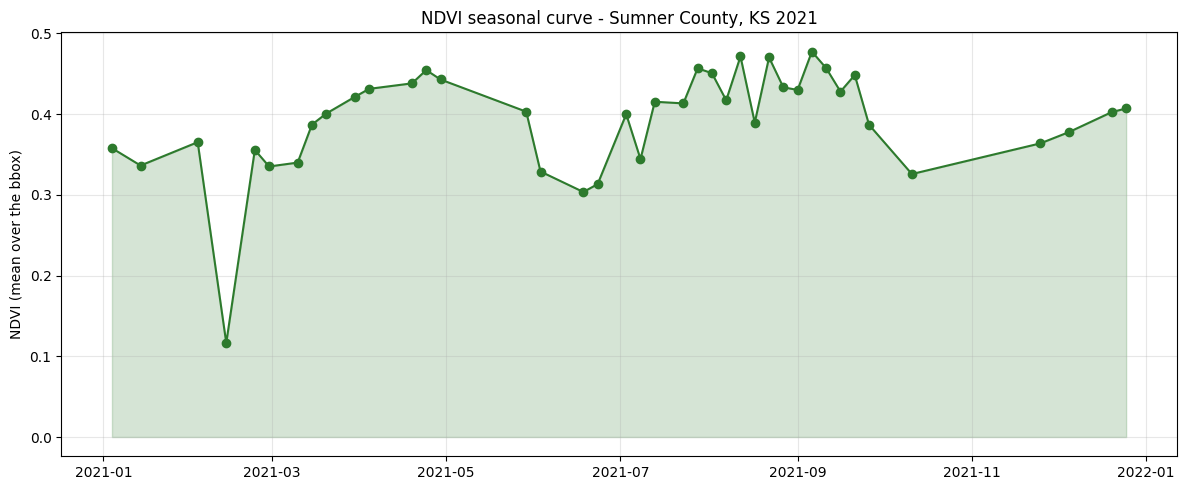

,date,ndvi
0,2021-01-04,0.357876
1,2021-01-14,0.336390
2,2021-02-03,0.365313
3,2021-02-13,0.116552
4,2021-02-23,0.355715


In [5]:
ndvi_ts = ndvi.mean(dim=["y", "x"]).compute()

df = pd.DataFrame({
    "date": pd.to_datetime(ndvi_ts["time"].values).date,
    "ndvi": ndvi_ts.values,
}).dropna().sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["date"], df["ndvi"], "o-", color="#2d7a2d")
ax.fill_between(df["date"], df["ndvi"], alpha=0.2, color="#2d7a2d")
ax.set_ylabel("NDVI (mean over the bbox)")
ax.set_title(f"NDVI seasonal curve - Sumner County, KS {YEAR}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df.head()

## 5. See it from above

The time series collapses every image to a single number. But each image is also a **spatial map** - let's see what it actually looks like.

We find the date with the highest NDVI (peak of the growing season) and display that scene with a red-yellow-green colormap. Bright green = thriving vegetation, red = bare or dormant.

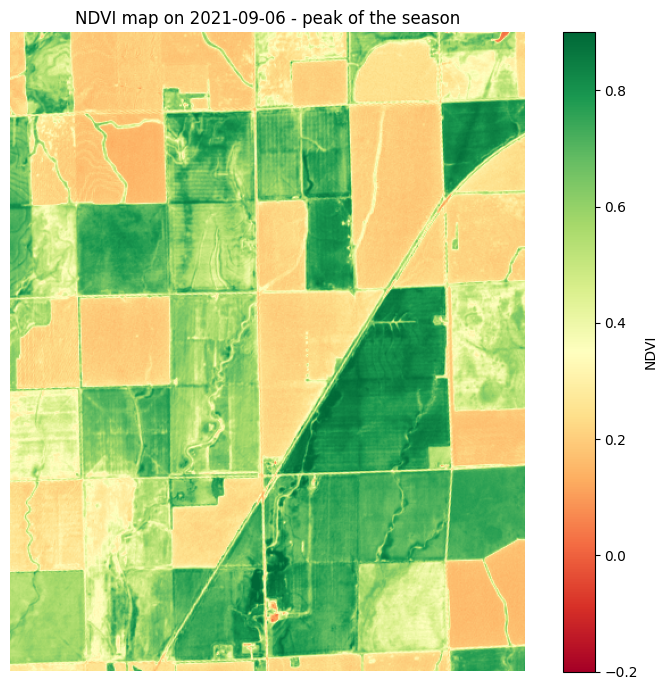

In [6]:
i_peak = int(np.argmax(np.nan_to_num(ndvi_ts.values, nan=-1)))
peak_date = pd.Timestamp(ndvi_ts["time"].values[i_peak]).date()
ndvi_peak_map = ndvi.isel(time=i_peak).compute()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(ndvi_peak_map.values, cmap="RdYlGn", vmin=-0.2, vmax=0.9)
plt.colorbar(im, ax=ax, label="NDVI")
ax.set_title(f"NDVI map on {peak_date} - peak of the season")
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. What you just did

In \~80 lines of code, on **100% free** infrastructure, you:

- Queried a catalog of petabytes of satellite imagery via a standard API (STAC).
- Loaded \~40 cloud-free scenes of a Kansas wheat field across an entire year.
- Computed a per-pixel vegetation index.
- Generated a seasonal curve and a peak-day map.

That curve **is** the raw material of every satellite crop signal in the industry.

## Where to go from here

What we did averages NDVI over **everything** in the bbox: wheat fields, roads, houses, river. Real signals isolate the crop of interest. In the **Medium** notebook (`02_medium.ipynb`) we add the USDA Cropland Data Layer to mask out everything that's not wheat, plus USDA NASS ground-truth yields and crop progress reports.

Then in the **Hard** notebook (`03_hard.ipynb`) we superimpose several seasons to spot anomalies - the actual trading signal.

All free. All your own work. No proprietary data anywhere.